In [ ]:
# 6.5. Unüberwachtes Clustering

## 1. Import Biblioteken

In [29]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## 2. Daten laden

In [30]:
# Bereinigten Datensatz laden

base_path = r"C:\Users\faink\Desktop\Achievement_6\02_data\2_cleaned"
plot_path = r"C:\Users\faink\Desktop\Achievement_6\05_visual"


df = pd.read_csv(os.path.join(base_path, "cleaned_data.csv"))

df.head()

,country_final,region_final,happiness_final,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final
0,Switzerland,Western Europe,7.587,1.39651,NaN,0.94143,0.66557,0.29678,0.41978
1,Iceland,Western Europe,7.561,1.30232,NaN,0.94784,0.62877,0.43630,0.14145
2,Denmark,Western Europe,7.527,1.32548,NaN,0.87464,0.64938,0.34139,0.48357
3,Norway,Western Europe,7.522,1.459,NaN,0.88521,0.66973,0.34699,0.36503
4,Canada,North America,7.427,1.32629,NaN,0.90563,0.63297,0.45811,0.32957


## 3. Variablen für Clustering auswählen

In [31]:
features = ["gdp_final", "social_support", "health_final",
            "freedom_final", "generosity", "corruption_final"]

df_cluster = df[features].dropna()

## 4. Standardisierung (z‑Score)

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final
0,-0.870175,1.897859,-0.967774,0.342274,0.726540,-0.068388
1,-0.835244,1.864968,-0.968175,0.364225,1.250334,-0.224174
2,-0.859534,1.891281,-0.967959,0.351055,1.237863,-0.024298
3,-0.861384,2.068897,-0.966539,0.324713,1.668123,-0.817921
4,-0.843572,1.756424,-0.966138,0.250079,1.063265,-0.174205


## 5. Elbow‑Methode (optimale Clusterzahl finden)

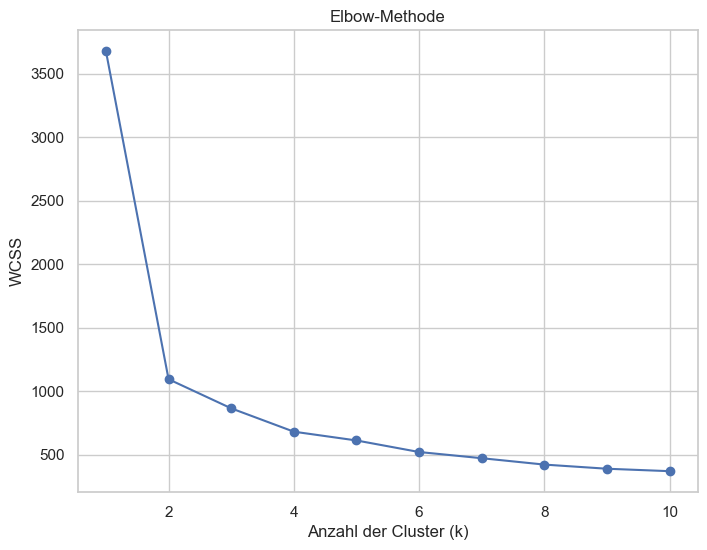

In [20]:
wcss = []  # Within-Cluster-Sum-of-Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow-Methode")
plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("WCSS")
plt.show()

6. k‑Means Clustering durchführen

In [32]:
# ---------------------------------------------------------
# k-Means Clustering mit k = 3
# ---------------------------------------------------------

os.environ["OMP_NUM_THREADS"] = "3"

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Clusterlabels hinzufügen
df_cluster["cluster"] = kmeans.labels_
df_cluster.head()

,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final,cluster
0,NaN,NaN,NaN,NaN,NaN,NaN,2
1,NaN,NaN,NaN,NaN,NaN,NaN,2
2,NaN,NaN,NaN,NaN,NaN,NaN,2
3,NaN,NaN,NaN,NaN,NaN,NaN,2
4,NaN,NaN,NaN,NaN,NaN,NaN,2


## 7. Cluster-Größen prüfen

In [10]:
df_cluster["cluster"].value_counts()

cluster
1    302
2    197
0    114
Name: count, dtype: int64

## 8. 2D‑Visualisierung der Cluster

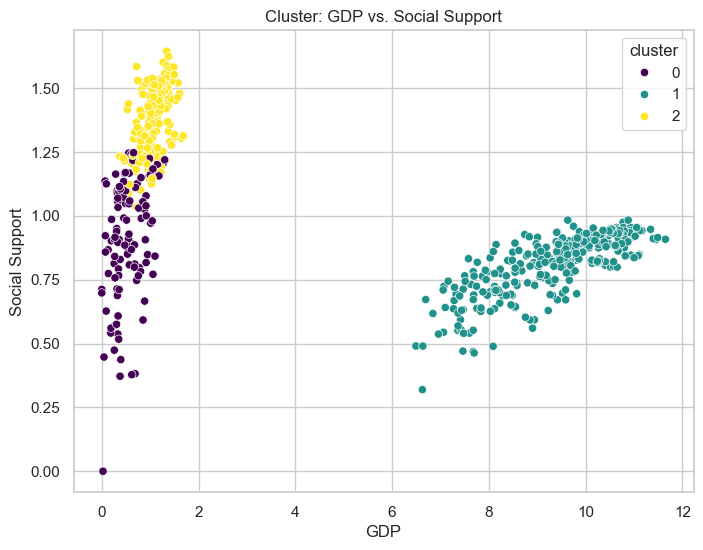

<Figure size 640x480 with 0 Axes>

In [12]:
# ---------------------------------------------------------
# Scatterplot: GDP vs. Social Support
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster["gdp_final"],
    y=df_cluster["social_support"],
    hue=df_cluster["cluster"],
    palette="viridis"
)
plt.title("Cluster: GDP vs. Social Support")
plt.xlabel("GDP")
plt.ylabel("Social Support")
plt.show()

plt.savefig(os.path.join(plot_path, "gdr.png"), dpi=300, bbox_inches="tight")

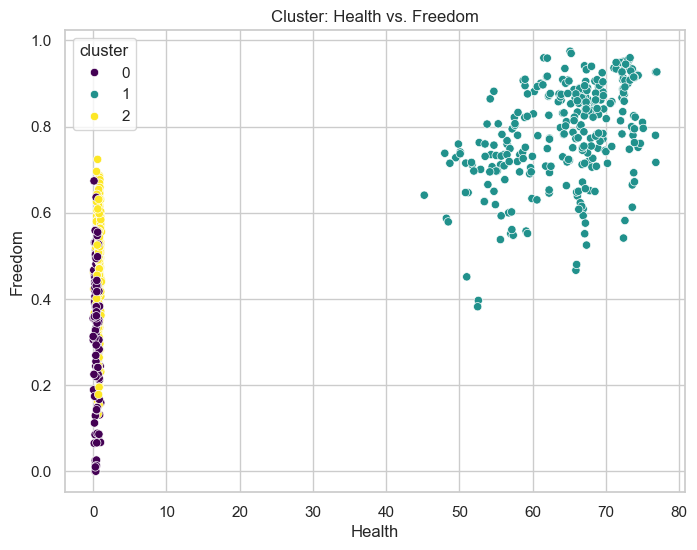

<Figure size 640x480 with 0 Axes>

In [13]:
# ---------------------------------------------------------
# Scatterplot: Health vs. Freedom
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster["health_final"],
    y=df_cluster["freedom_final"],
    hue=df_cluster["cluster"],
    palette="viridis"
)
plt.title("Cluster: Health vs. Freedom")
plt.xlabel("Health")
plt.ylabel("Freedom")
plt.show()

plt.savefig(os.path.join(plot_path, "cluster_health_freedom.png"), dpi=300, bbox_inches="tight")

## 9. Grafiken als PNG speicher

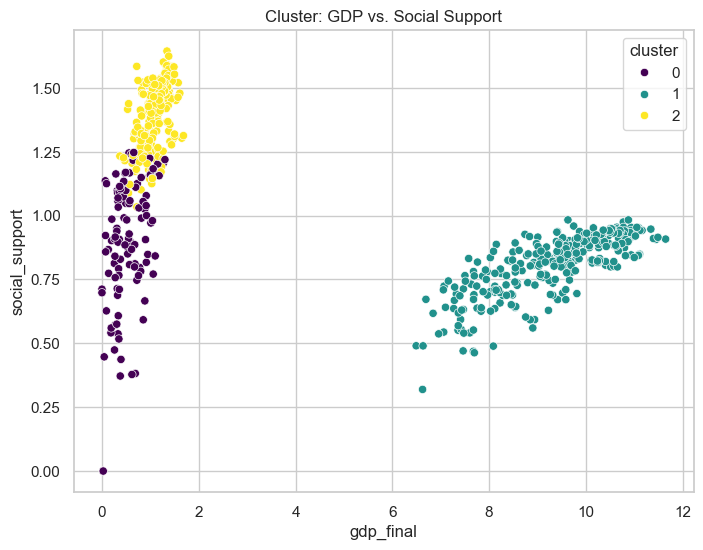

In [14]:
# GDP vs Social Support

plot1_path = os.path.join(plot_path, "cluster_gdp_social.png")
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster["gdp_final"],
    y=df_cluster["social_support"],
    hue=df_cluster["cluster"],
    palette="viridis"
)
plt.title("Cluster: GDP vs. Social Support")
plt.savefig(plot1_path, dpi=300, bbox_inches="tight")
plt.show()

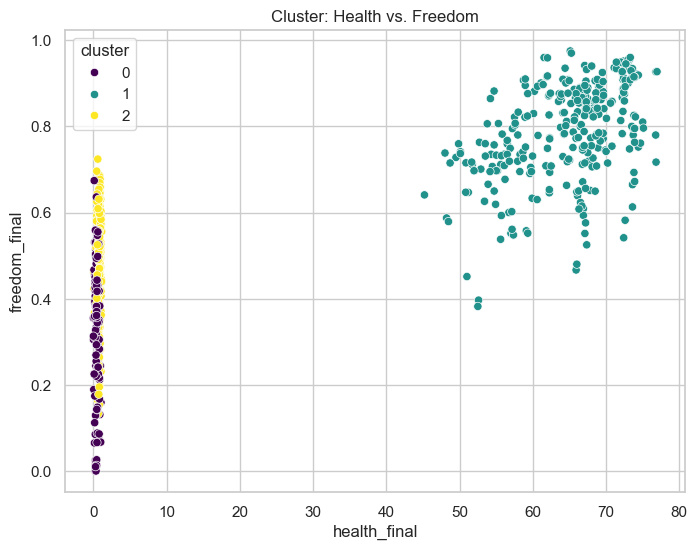

In [15]:
# Health vs Freedom

plot2_path = os.path.join(plot_path, "cluster_health_freedom.png")
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster["health_final"],
    y=df_cluster["freedom_final"],
    hue=df_cluster["cluster"],
    palette="viridis"
)
plt.title("Cluster: Health vs. Freedom")
plt.savefig(plot2_path, dpi=300, bbox_inches="tight")
plt.show()

### Unüberwachtes Lernen und k-Means Clustering

Beim unüberwachten maschinellen Lernen gibt es keine abhängige Variable.  
Der Algorithmus sucht selbstständig nach Mustern und gruppiert ähnliche Datenpunkte in Cluster.

Für diese Analyse wurde der k-Means Algorithmus verwendet.  
Die Variablen wurden zunächst standardisiert (z‑Score), um gleiche Skalen sicherzustellen.  
Mit der Elbow-Methode wurde die optimale Anzahl von Clustern bestimmt.

Die Cluster zeigen Gruppen von Ländern mit ähnlichen Profilen in Bezug auf  
Wirtschaftskraft, soziale Unterstützung, Gesundheit, Freiheit, Großzügigkeit und Korruption.  
Die Visualisierungen helfen dabei, Unterschiede zwischen den Gruppen zu erkennen  
und Muster zu identifizieren, die in der reinen Tabellenform nicht sichtbar wären.

In [28]:
df_cluster.to_csv(os.path.join(base_path, "df_cluster.csv"), index=False)